Dados Utilizados

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [29]:
df = pd.read_csv("dados_tratados.csv")

df.head()

,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Churn                      7043 non-null   object
 1   customer_gender            7267 non-null   object
 2   customer_SeniorCitizen     7267 non-null   int64 
 3   customer_Partner           7267 non-null   object
 4   customer_Dependents        7267 non-null   object
 5   customer_tenure            7267 non-null   int64 
 6   phone_PhoneService         7267 non-null   object
 7   phone_MultipleLines        7267 non-null   object
 8   internet_InternetService   7267 non-null   object
 9   internet_OnlineSecurity    7267 non-null   object
 10  internet_OnlineBackup      7267 non-null   object
 11  internet_DeviceProtection  7267 non-null   object
 12  internet_TechSupport       7267 non-null   object
 13  internet_StreamingTV       7267 non-null   object
 14  internet

In [31]:
df.describe()

,customer_SeniorCitizen,customer_tenure
count,7267.000000,7267.000000
mean,0.162653,32.346498
std,0.369074,24.571773
min,0.000000,0.000000
25%,0.000000,9.000000
50%,0.000000,29.000000
75%,0.000000,55.000000
max,1.000000,72.000000


Limpeza

In [32]:
df = df.drop(columns=['customerID'], errors='ignore')

Convertendo variáveis

In [33]:
df = pd.get_dummies(df, drop_first=True)

In [34]:
df.head()

,customer_SeniorCitizen,customer_tenure,Churn_Yes,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,phone_MultipleLines_Yes,internet_InternetService_Fiber optic,...,"account_Charges_{'Monthly': 99.9, 'Total': '5706.3'}","account_Charges_{'Monthly': 99.9, 'Total': '6137'}","account_Charges_{'Monthly': 99.9, 'Total': '6241.35'}","account_Charges_{'Monthly': 99.9, 'Total': '7251.7'}","account_Charges_{'Monthly': 99.95, 'Total': '1132.75'}","account_Charges_{'Monthly': 99.95, 'Total': '1931.75'}","account_Charges_{'Monthly': 99.95, 'Total': '2292.75'}","account_Charges_{'Monthly': 99.95, 'Total': '3186.65'}","account_Charges_{'Monthly': 99.95, 'Total': '3767.4'}","account_Charges_{'Monthly': 99.95, 'Total': '547.65'}"
0,0,9,False,False,True,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,False,True,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,True,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,1,13,True,True,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,1,3,True,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


Verificando balanceamento da variável churn

In [39]:
df['Churn_Yes'].value_counts()

,count
Churn_Yes,
False,5398
True,1869


In [41]:
df['Churn_Yes'].value_counts(normalize=True)

,proportion
Churn_Yes,
False,0.74281
True,0.25719


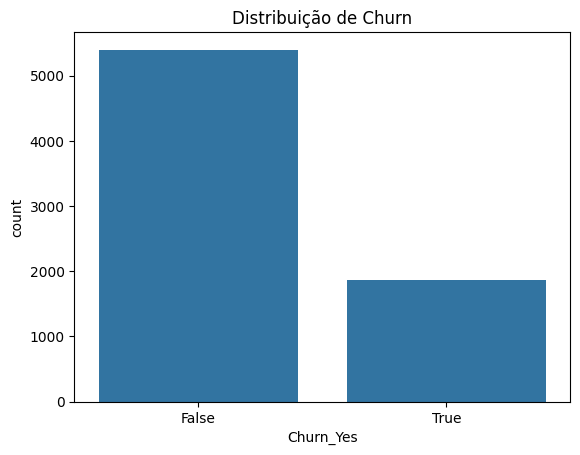

In [43]:
sns.countplot(x='Churn_Yes', data=df)
plt.title("Distribuição de Churn")
plt.show()

In [ ]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()